In [94]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import host_subplot
plt.rcParams['text.usetex'] = True

In [95]:
F = 96485 # C/mol
R = 8.314 # J/(mol * k)
T = 300 # K
n = 5
k0_1 = 2 # ms^-1
k0_2 = 1 # ms^-1
z_1 = 1
z_2 = 0
Ca_conc_cyto_0 = 0.1e-6 # M
#Ca_conc_e = 3e-6 # M
Ca_conc_e = 40e-3 # M
s_0 = 20
#P_Ca = .00001 # ms^-1
P_Ca = 10e-6 # m / s
#P_Ca = 4.3e-8 # ms^-1
V_0 = -70e-3 # V
V_neuron = 5.48e-11 # L
#V_neuron_L = V_neuron * 0.000000000000001 # L
C_membrane = 20e-2 # F/m^2 or C / V m^2
A_neuron = .000000350 # m^2
#g_Ca = 0.00032 # A / V m^2

In [219]:
def k_1(V, k0_1, z_1):
    return k0_1 * np.exp(F * z_1 * V / R / T)

def k_2(V):
    return k0_2 * np.exp(F * z_2 * V / R / T)

def o_hat(V,k):
    return k_1(V, k, z_1) / (k_1(V, k, z_1)+k_2(V))

def current_to_molar_per_second(I, z):
    return -I / (z * F)

def i_ca(V, c_i, o):
    if np.abs(V) <= 0.00000001:
        i = P_Ca * 2 * F * 1e3 * (c_i - Ca_conc_e) # L'Hopital's
    else:
        i = P_Ca * 4 * (F / R) * (F / T) * 1e3 * V * (c_i - Ca_conc_e * np.exp(-2*F*V / (R * T))) / (1 - np.exp(-2*F*V / (R * T)))
    return i

def I_Ca(V, c_i, o):
    i = i_ca(V, c_i, o)
    return s_0 * i * o**n
    

def dodt(V, o, k0_1, z_1):
    return k_1(V,k0_1, z_1) * (1-o) -k_2(V) * o

In [220]:
def voltage_plot(title, k):
    Vs = np.linspace(-.07,.07)
    o_hats = list(map(lambda v: o_hat(v,k)**5, Vs))
    i_cs = list(map(lambda v: i_ca(v, Ca_conc_cyto_0, o_hat(v,k)), Vs))
    I_Cas = list(map(lambda v: I_Ca(v, Ca_conc_cyto_0, o_hat(v,k)), Vs))
    #plt.plot(Vs, o_hats)
    host  = host_subplot(111)
    host.plot(Vs*1e3, i_cs, linewidth=3, label=r"$i$")
    host.plot(Vs*1e3, I_Cas, linewidth=3, label=r"$I_{Ca}$")
    host.legend(fontsize=20)
    par = host.twinx()
    par.plot(Vs*1e3, o_hats, linewidth=3, label=r"$o_\infty^5$", linestyle='--')
    par.set_ylabel(r"$o_\infty^5$", fontsize=18)
    host.legend(fontsize=18)
    host.xaxis.set_tick_params(labelsize=14)
    host.yaxis.set_tick_params(labelsize=16)
    par.yaxis.set_tick_params(labelsize=16)
    #host.yicks(fontsize=14)
    host.set_xlabel("$V$ (mV)", fontsize=20)
    host.set_ylabel(r"$I_{Ca}$ (pA/($\mu$m)$^2$)", fontsize=20)
    host.set_title(title, fontsize = 26)

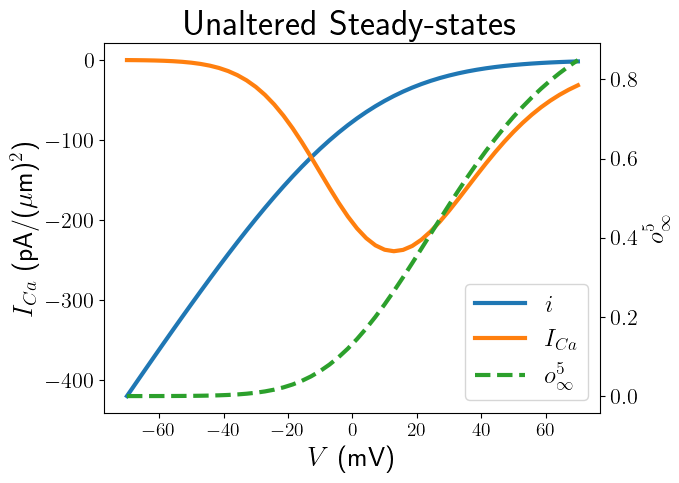

In [221]:
voltage_plot("Unaltered Steady-states", 2)

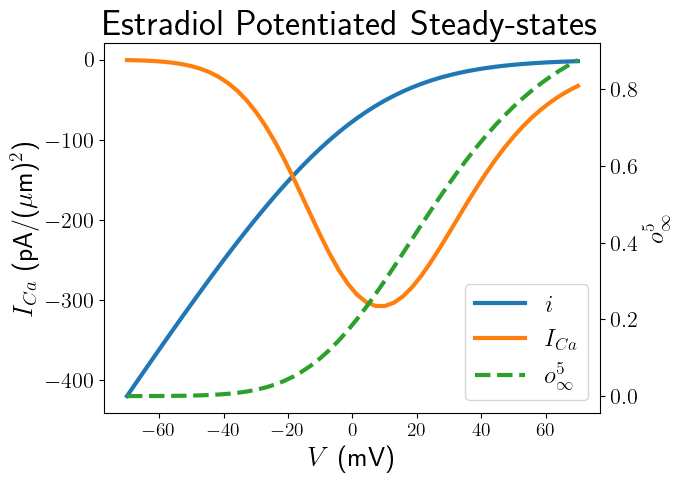

In [222]:
voltage_plot("Estradiol Potentiated Steady-states", 2.5)

In [223]:
# integrate
def dParams(t, params):
    V = params[0]
    o = params[1]
    
    return np.array([-I_Ca(V, Ca_conc_cyto_0, o)/C_membrane, dodt(V, o, 2, z_1)])
    #return np.array([0, dodt(V,o)])
    
#params_0 = np.array([V_0, o_hat(V_0)])
params_0 = np.array([-0.02, 0])
t_span = [0,0.5]
sol = solve_ivp(dParams, t_span, params_0)

Text(0.5, 0, 'Time (s)')

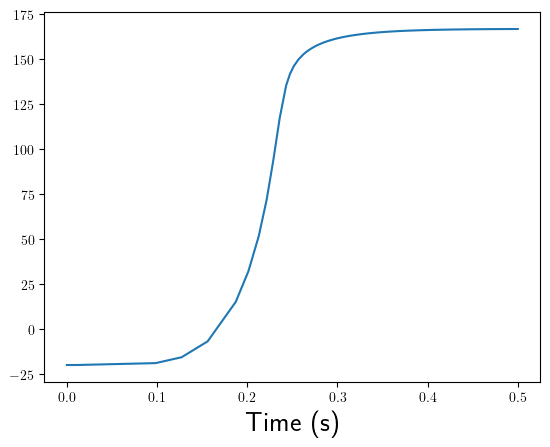

In [224]:
plt.plot(sol.t, sol.y[0]*1e3)
plt.xlabel("Time (s)", fontsize = 20)
plt.xlabel("Time (s)", fontsize = 20)

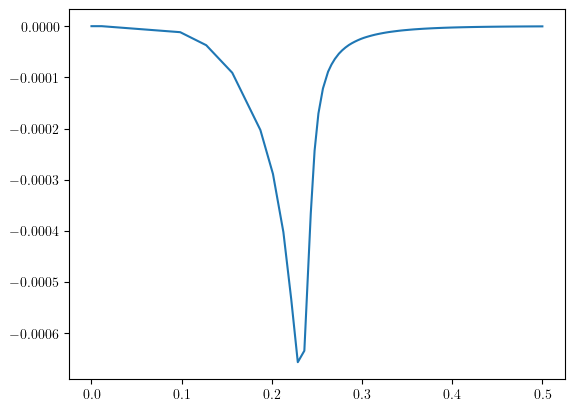

In [225]:
res = np.array(list(map(lambda x: I_Ca(x[0], Ca_conc_cyto_0, x[1])*10**-3, zip(sol.y[0], sol.y[1]))))
plt.plot(sol.t, res)

In [226]:
current_to_molar_per_second(-0.0006,2)

3.109291599730528e-09

In [227]:
Na_conc_out = .14 # M
Na_conc_in = .02 # M

def J_NCX(V):
    return Ca_conc_e * (Na_conc_out / Na_conc_in)**3 * np.exp(F * V / R / T)

In [228]:
# integrate
def dParams(t, params):
    V = params[0]
    o = params[1]
    c = params[2]
    
    I = I_Ca(V, c, o)
    return np.array([-I/C_membrane, dodt(V, o, 3, z_1), current_to_molar_per_second(I,2)])
    #return np.array([0, dodt(V,o)])

#params_0 = np.array([V_0, o_hat(V_0)])
params_0 = np.array([-0.04, 0, Ca_conc_cyto_0])
t_span = [0,3]
sol = solve_ivp(dParams, t_span, params_0)

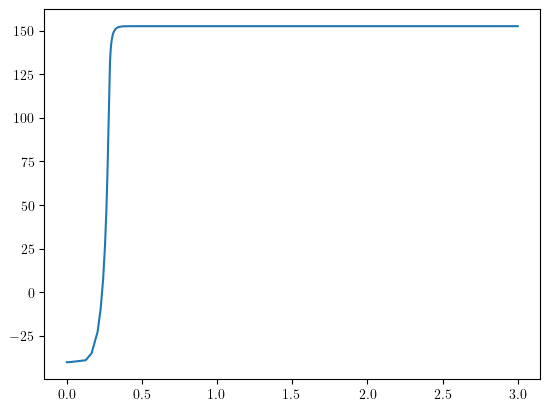

In [229]:
#plt.plot(sol.t, sol.y[0])
plt.plot(sol.t, sol.y[0]*1e3)

In [237]:
# integrate
def dParams(t, params):
    V = params[0]
    o = params[1]
    c = params[2]
    if t <= 6:
        z = 2
    else:
        z = 2.5
    
    I = I_Ca(V, c, o)
    return np.array([0, dodt(V, o, z, z_1), current_to_molar_per_second(I,2)])
    #return np.array([0, dodt(V,o)])

def get_res(V):
    params_0 = np.array([V, 0, Ca_conc_cyto_0])
    t_span = [0,12]
    sol = solve_ivp(dParams, t_span, params_0, max_step = 0.01)
    res = np.array(list(map(lambda x: I_Ca(x[0], Ca_conc_cyto_0, x[1]), zip(sol.y[0], sol.y[1]))))
    return sol.t, res
#params_0 = np.array([V_0, o_hat(V_0)])

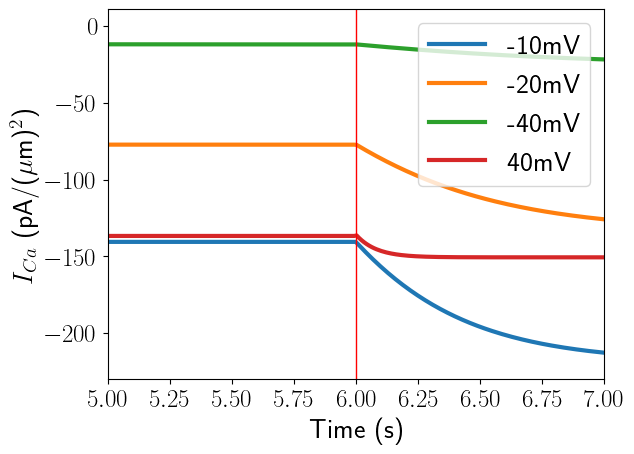

In [239]:
t, res = get_res(-0.01)
plt.plot(t, res, linewidth = 3, label=r"-10mV")
t, res = get_res(-0.02)
plt.plot(t, res, linewidth = 3, label=r"-20mV")
t, res = get_res(-0.04)
plt.plot(t, res, linewidth = 3, label=r"-40mV")
t, res = get_res(0.04)
plt.plot(t, res, linewidth = 3, label=r"40mV")
plt.xlim([5,7])
plt.legend(fontsize=20)
plt.axvline(6, color="red", linewidth=1)
plt.xlabel("Time (s)", fontsize=20)
plt.ylabel(r"$I_{Ca}$ (pA/($\mu$m)$^2$)", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

#params_0 = np.array([0.04, 0, Ca_conc_cyto_0])
#t_span = [0,12]
#sol = solve_ivp(dParams, t_span, params_0)
#res = np.array(list(map(lambda x: I_Ca(x[0], Ca_conc_cyto_0, x[1])*10**-3, zip(sol.y[0], sol.y[1]))))
#plt.plot(sol.t, res)
();